In [3]:
from sklearn.datasets import load_iris
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import timeit
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.metrics import accuracy_score

## **Load in the dataset**
First, we need to load in the iris dataset. sklearn already has this particular dataset 'built-in', so we can just import it.
Also using a dataframe to help visualize the data more easily, for an initial look.

In [4]:
data = load_iris()
x, y = data.data, data.target
df = load_iris(as_frame=True)
print(df.data)

     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                  5.1               3.5                1.4               0.2
1                  4.9               3.0                1.4               0.2
2                  4.7               3.2                1.3               0.2
3                  4.6               3.1                1.5               0.2
4                  5.0               3.6                1.4               0.2
..                 ...               ...                ...               ...
145                6.7               3.0                5.2               2.3
146                6.3               2.5                5.0               1.9
147                6.5               3.0                5.2               2.0
148                6.2               3.4                5.4               2.3
149                5.9               3.0                5.1               1.8

[150 rows x 4 columns]


In [5]:
print(df['target'])

0      0
1      0
2      0
3      0
4      0
      ..
145    2
146    2
147    2
148    2
149    2
Name: target, Length: 150, dtype: int64


I wanted to get more familiar with both the dataset and some syntax, so these blocks below show some tests to dig more into what this dataset holds. Simple counts, numpy functions, and others are used to help as a refreasher and mess with the data.

In [6]:
print(x.shape)
print(y.shape)

(150, 4)
(150,)


In [7]:
types = data.target_names
print(types)

['setosa' 'versicolor' 'virginica']


In [8]:
features = data.feature_names
print(features)

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [9]:
(unique_labels, counts) = np.unique(y, return_counts=True)
print(unique_labels)
print(counts)

[0 1 2]
[50 50 50]


In [10]:
target_0 = x[y==0]
print(target_0)

[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]
 [5.4 3.9 1.7 0.4]
 [4.6 3.4 1.4 0.3]
 [5.  3.4 1.5 0.2]
 [4.4 2.9 1.4 0.2]
 [4.9 3.1 1.5 0.1]
 [5.4 3.7 1.5 0.2]
 [4.8 3.4 1.6 0.2]
 [4.8 3.  1.4 0.1]
 [4.3 3.  1.1 0.1]
 [5.8 4.  1.2 0.2]
 [5.7 4.4 1.5 0.4]
 [5.4 3.9 1.3 0.4]
 [5.1 3.5 1.4 0.3]
 [5.7 3.8 1.7 0.3]
 [5.1 3.8 1.5 0.3]
 [5.4 3.4 1.7 0.2]
 [5.1 3.7 1.5 0.4]
 [4.6 3.6 1.  0.2]
 [5.1 3.3 1.7 0.5]
 [4.8 3.4 1.9 0.2]
 [5.  3.  1.6 0.2]
 [5.  3.4 1.6 0.4]
 [5.2 3.5 1.5 0.2]
 [5.2 3.4 1.4 0.2]
 [4.7 3.2 1.6 0.2]
 [4.8 3.1 1.6 0.2]
 [5.4 3.4 1.5 0.4]
 [5.2 4.1 1.5 0.1]
 [5.5 4.2 1.4 0.2]
 [4.9 3.1 1.5 0.2]
 [5.  3.2 1.2 0.2]
 [5.5 3.5 1.3 0.2]
 [4.9 3.6 1.4 0.1]
 [4.4 3.  1.3 0.2]
 [5.1 3.4 1.5 0.2]
 [5.  3.5 1.3 0.3]
 [4.5 2.3 1.3 0.3]
 [4.4 3.2 1.3 0.2]
 [5.  3.5 1.6 0.6]
 [5.1 3.8 1.9 0.4]
 [4.8 3.  1.4 0.3]
 [5.1 3.8 1.6 0.2]
 [4.6 3.2 1.4 0.2]
 [5.3 3.7 1.5 0.2]
 [5.  3.3 1.4 0.2]]


In [11]:
tmean = np.mean(target_0[:5], axis=0)
print(tmean)

[4.86 3.28 1.4  0.2 ]


## **Plot** 

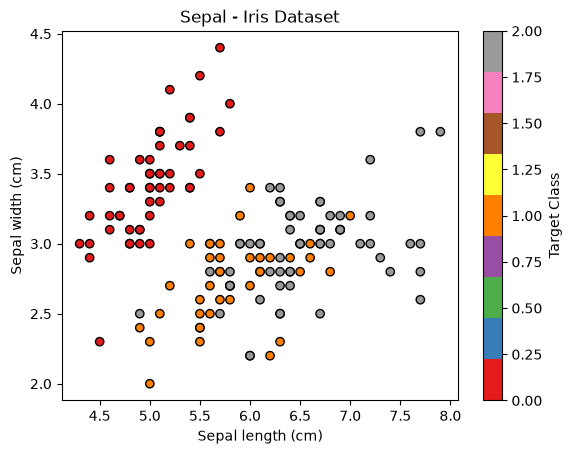

In [12]:
plt.figure()
plt.scatter(x[:,0], x[:,1], c=y, cmap=plt.cm.Set1, edgecolor='k')
plt.xlabel(features[0].capitalize())
plt.ylabel(features[1].capitalize())
plt.title("Sepal - Iris Dataset")
plt.colorbar(label="Target Class")
plt.show()

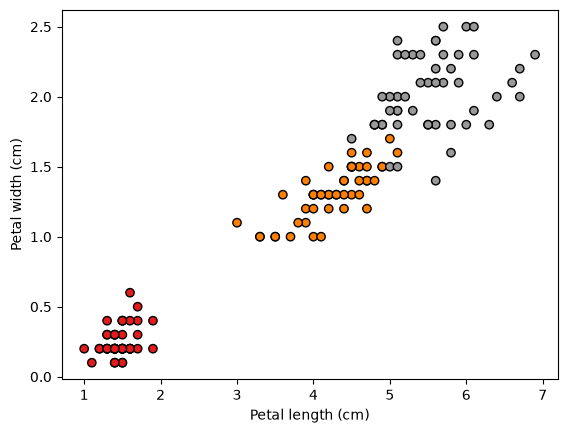

In [13]:
plt.figure()
plt.scatter(x[:,2], x[:,3], c=y, cmap=plt.cm.Set1, edgecolor='k')
plt.xlabel(features[2].capitalize())
plt.ylabel(features[3].capitalize())
plt.show()

## **Splitting the Dataset**
Here we can easily split the dataset we have into a nice 80/20 split for training/testing respectively using sklearn. Note we're setting the random state to 42 - any valid integer from 0-42 will work, it's just common for one of those two end values to be used. This allows for a specific reproduceability so our "random" values picked are consistent between runs.

In [14]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

Just seeing the length of our new variables to see if the split did occur and was correct - so far everything checks out.

In [15]:
print(len(x_train), len(y_train))
print(len(x_test), len(y_test))

120 120
30 30


## **Pipeline**
Here we create the pipeline used to help simplify and package the necessary standardizing and supervised learning technique we're going to use. We could do these steps more individually by creating new variables to represent our scaled data for testing/training, as well as applying our learning technique - a pipeline helps consolidate these aspects, which we can just use for other datasets. Kind of like a nice helper function.

In our case, we're sticking with using **z-score normalization** as our scaling technique and **logistic regression** as our learning technique for this classification problem.

In [16]:
pipeline = Pipeline([("scalar", StandardScaler()),
                     ("model", LogisticRegression())
                    ])

In [23]:
pipeline.fit(x_train, y_train)
y_prediction = pipeline.predict(x_test)
print(y_prediction)
print(y_test)

[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]
[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]


Recording the time in milliseconds of the training and testing pipelines.

In [31]:
train_time = timeit.timeit(lambda:pipeline.fit(x_train, y_train), number=1)
test_time = timeit.timeit(lambda:pipeline.predict(x_test), number=1)

print(train_time * 1000)
print(test_time * 1000)

5.57819998357445
0.4276999970898032


So...how well did our model do in the end? We can compare the differences found in our ground truth (y_test) and what the predicted values were based on the input x_test data.

In [32]:
accuracy = accuracy_score(y_test, y_prediction)
print(f"Model accuracy: {accuracy}")

Model accuracy: 1.0


## **K-Fold Cross Validation**
Seeing how the model on this iteration achieved an accuracy of 100%, I was curious on whether there were ways to validate this seemingly high success. K-fold cross validation showed up as a method to determine how robust a model can be to generalize to newer unseen data. It works by splitting the dataset into an even number of K subsets (non-overlapping). It then cycles through each subset, having 1 serve as the test data and the rest of the subsets as training data. This repeats until every subset has acted as a test/training data subset. So instead of just relying on a single 80/20 split that *could* be lucky and give up optimal/poor results, we can test the model on K different data subsets to further see how well it can do.

With K=5 subsets, we can note that overall, the model as is has a mean test_score of 0.958, which may be more representative of the model's actual capability in this classification problem.

In [51]:
results_dict = cross_validate(pipeline, x_train, y_train, cv=5)
print(results_dict.keys())
print(results_dict['test_score'])
print(results_dict['test_score'].mean())

dict_keys(['fit_time', 'score_time', 'test_score'])
[0.95833333 1.         0.875      1.         0.95833333]
0.9583333333333334
